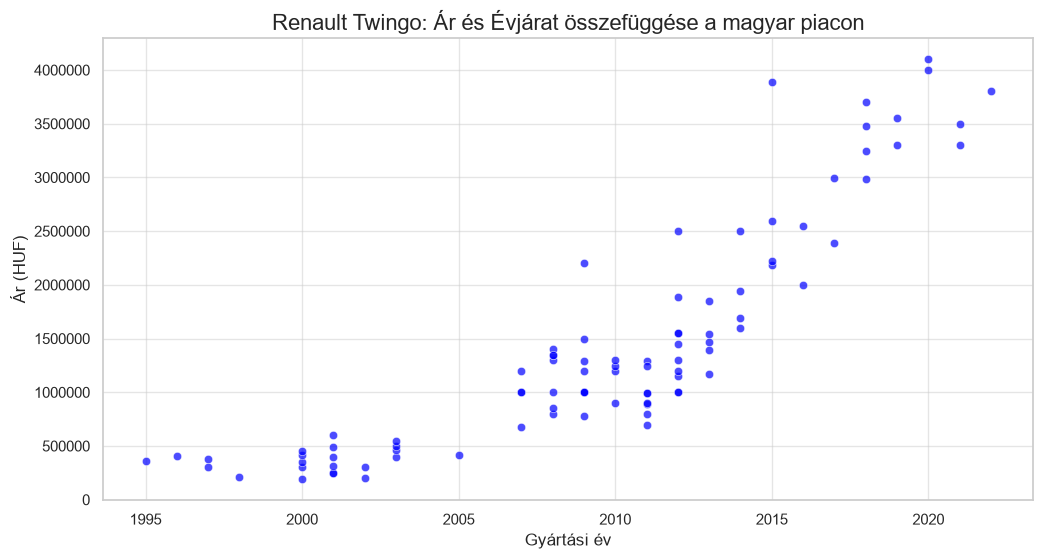

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# A grafikonok stílusának beállítása (profi, letisztult kinézet)
sns.set_theme(style="whitegrid")

# 1. Adatbetöltés
df = pd.read_csv("cleaned_cars_data.csv")

# 2. Rajztábla (Figure) létrehozása
plt.figure(figsize=(12, 6))

# 3. Szórásdiagram (Scatterplot): Ár vs. Évjárat
# Lássuk, hogyan drágulnak az autók az évjárat előrehaladtával!
sns.scatterplot(
    data=df,
    x="Year",
    y="Price_Clean",
    alpha=0.7,      # Enyhe átlátszóság a sok pont miatt
    color="blue"
)

# 4. Formázás
plt.title("Renault Twingo: Ár és Évjárat összefüggése a magyar piacon", fontsize=16)
plt.xlabel("Gyártási év", fontsize=12)
plt.ylabel("Ár (HUF)", fontsize=12)

# A számok formázása az Y tengelyen (ne tudományos formátumban mutassa a milliókat)
plt.ticklabel_format(style='plain', axis='y')

plt.show()

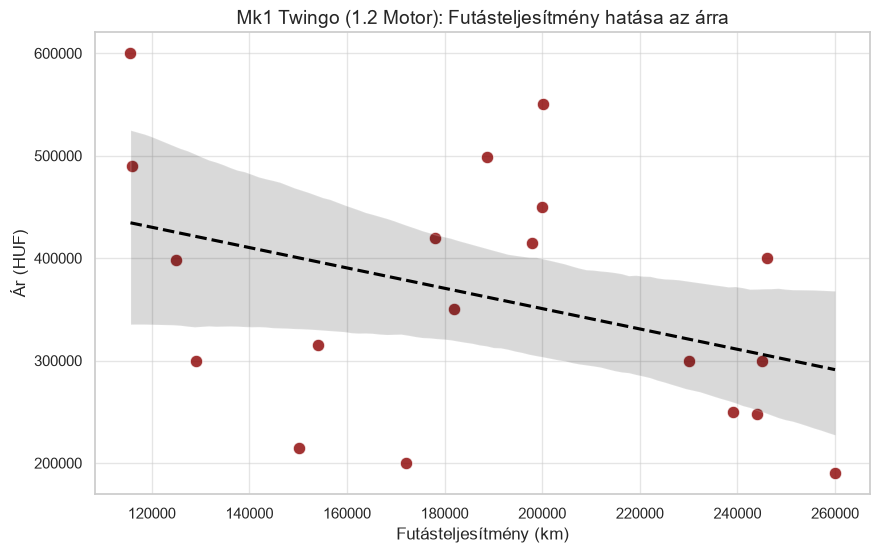

In [2]:
# 1. Szűrjük le az adatbázist a klasszikus "Mk1" generációra (kb. 2006-ig)
# és ragaszkodjunk a legendás 1149 cm³-es (pl. D7F) motorokhoz!
df_mk1 = df[(df['Year'] <= 2006) & (df['Engine_cm3'] == 1149)]

plt.figure(figsize=(10, 6))

# 2. Szórásdiagram: Futásteljesítmény vs. Ár
sns.scatterplot(
    data=df_mk1,
    x="Mileage_km",
    y="Price_Clean",
    color="darkred",
    s=80, # Pöttyök mérete
    alpha=0.8
)

# 3. Trendvonal (Regresszió) hozzáadása, hogy lássuk az áresés statisztikai mértékét
sns.regplot(
    data=df_mk1,
    x="Mileage_km",
    y="Price_Clean",
    scatter=False,
    color="black",
    line_kws={"linestyle": "--"}
)

plt.title("Mk1 Twingo (1.2 Motor): Futásteljesítmény hatása az árra", fontsize=14)
plt.xlabel("Futásteljesítmény (km)", fontsize=12)
plt.ylabel("Ár (HUF)", fontsize=12)

# Tengelyek formázása (hogy ne 1e5 formátumban mutassa a százezreket)
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')

plt.show()